In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

server = r"SUFILAPTOP\SQLEXPRESS"
database = "healthcare"

driver = quote_plus("ODBC Driver 17 for SQL Server")

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"
)

print("✅ Connected Successfully")

healthcare_data = pd.read_sql(text("SELECT * FROM [dbo].[healthcare_data]"), engine)

print("✅ All tables imported successfully!")

tables = {
    "healthcare_data": healthcare_data
}

for name, df in tables.items():
    print(f"\n{name}")
    print(f"Shape: {df.shape}")

✅ Connected Successfully
✅ All tables imported successfully!

healthcare_data
Shape: (54966, 15)


# **1. Descriptive Analysis**

## Business Objective:

- **Summarize the key characteristics of patient age, billing amount, and length of stay to establish baseline operational and financial metrics for the hospital.**

In [15]:
pd.set_option("display.float_format", "{:.2f}".format)

In [17]:
df[['date_of_admission', 'discharge_date']].dtypes

date_of_admission    object
discharge_date       object
dtype: object

In [24]:
# converting object to time
df["date_of_admission"] = pd.to_datetime(df["date_of_admission"], dayfirst=True)
df["discharge_date"] = pd.to_datetime(df["discharge_date"], dayfirst=True)

In [25]:
df["length_of_stay"] = (
    df["discharge_date"] - df["date_of_admission"]
).dt.days

In [26]:
numerical_columns = [
    "age",
    "billing_amount",
    "length_of_stay"
]

In [27]:
# mean , median , standard deviation , minimum , maximum
descriptive_statistics = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Standard Deviation": df[numerical_columns].std(),
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max()
})

descriptive_statistics = descriptive_statistics.round(2)

descriptive_statistics

,Mean,Median,Standard Deviation,Minimum,Maximum
age,51.54,52.00,19.61,13.00,89.00
billing_amount,25544.31,25542.75,14208.41,-2008.49,52764.28
length_of_stay,15.50,15.00,8.66,1.00,30.00


## **Business Insights**:

• The average patient age provides an overview of the hospital's primary patient demographic.

• The average billing amount establishes a financial benchmark for patient treatment costs.

• The standard deviation of billing amount indicates the level of variability in healthcare expenses across patients.

• The average length of stay reflects typical hospitalization duration and provides insight into hospital resource utilization.

• Comparing minimum and maximum values helps identify the overall range of patient characteristics and treatment costs.

# **2. Distribution Analysis**

## Business Objective:

- **Analyze the distribution of key numerical variables to identify data patterns, detect outliers, and understand whether patient age, billing amount, and length of stay follow a normal distribution.**

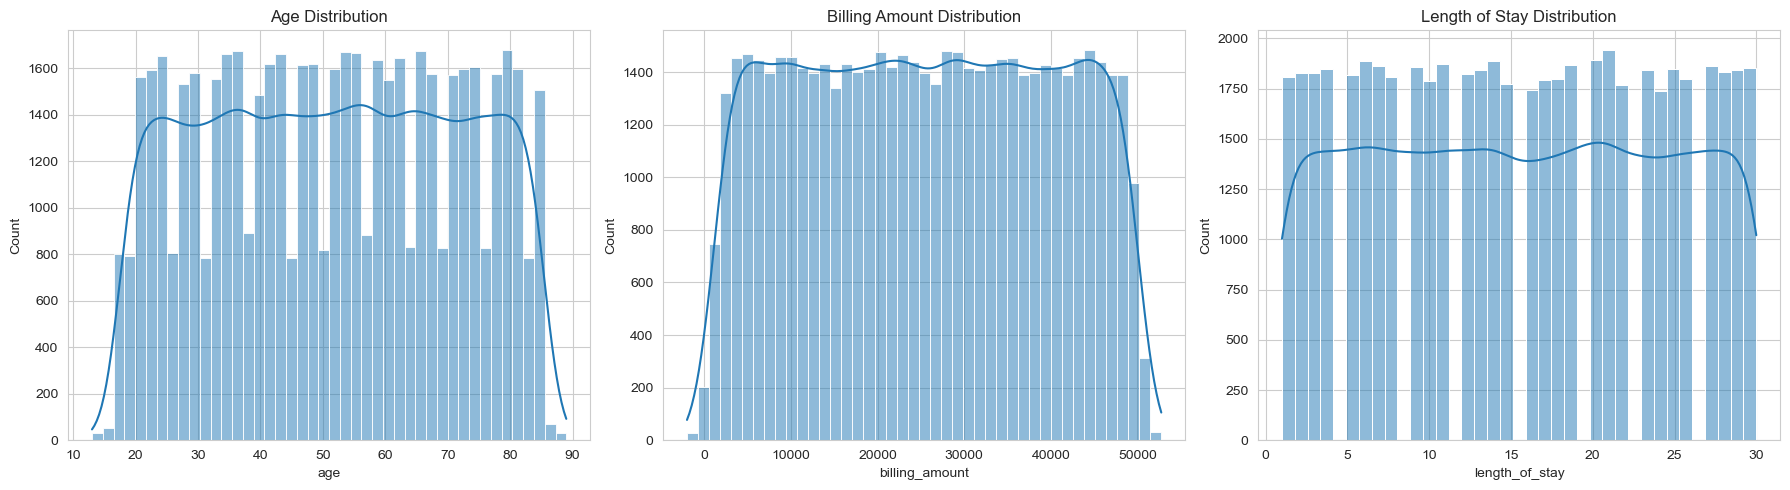

In [28]:
#Histogram + KDE

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df["age"], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["billing_amount"], kde=True, ax=axes[1])
axes[1].set_title("Billing Amount Distribution")

sns.histplot(df["length_of_stay"], kde=True, ax=axes[2])
axes[2].set_title("Length of Stay Distribution")

plt.tight_layout()
plt.show()

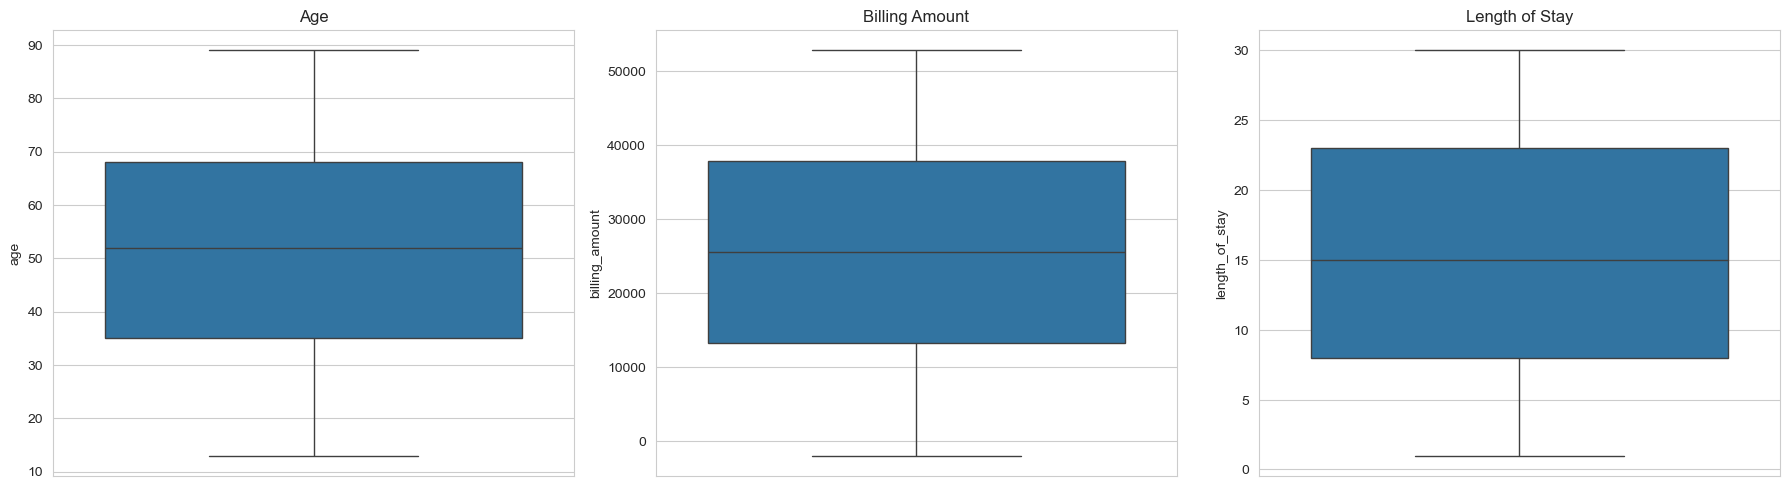

In [29]:
#Boxplots

fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(y=df["age"], ax=axes[0])
axes[0].set_title("Age")

sns.boxplot(y=df["billing_amount"], ax=axes[1])
axes[1].set_title("Billing Amount")

sns.boxplot(y=df["length_of_stay"], ax=axes[2])
axes[2].set_title("Length of Stay")

plt.tight_layout()
plt.show()

# **Business Insights:**

• The age distribution indicates whether the hospital primarily serves younger, middle-aged, or older patients.

• The billing amount distribution reveals whether healthcare costs are concentrated around a typical value or influenced by a small number of high-cost cases.

• The length of stay distribution provides insight into hospitalization patterns and resource utilization.

• Boxplots highlight potential outliers that may represent unusually expensive treatments or extended hospitalizations requiring further investigation.

# **3. Correlation Analysis**

# **Business Objective:**

- **Analyze the relationships between patient age, billing amount, and length of stay to identify whether these variables are associated and how they may influence healthcare costs.**

In [48]:
#Correlation Matrix
corr_matrix = df[["age", "billing_amount", "length_of_stay"]].corr()

corr_matrix

,age,billing_amount,length_of_stay
age,1.00,-0.00,0.01
billing_amount,-0.00,1.00,-0.00
length_of_stay,0.01,-0.00,1.00


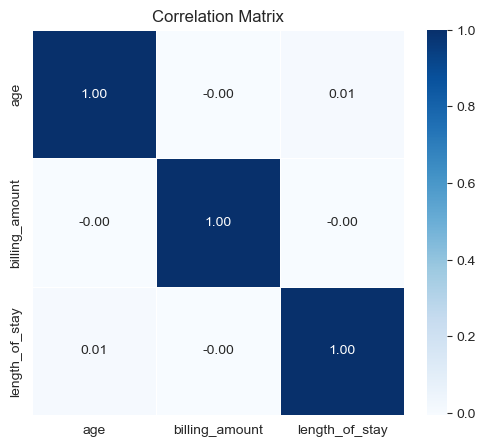

In [49]:
#Correlation Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

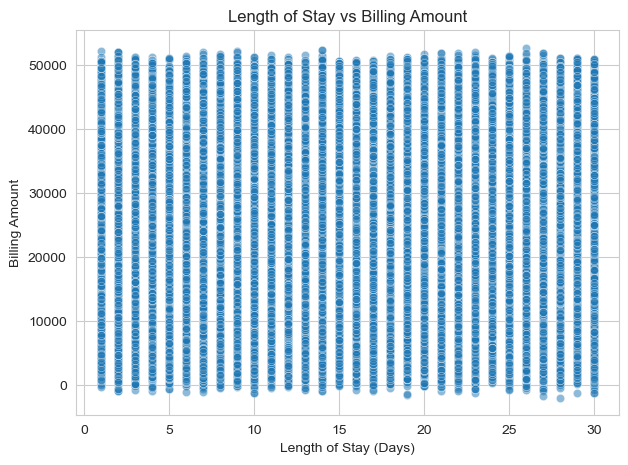

In [50]:
# scatter plot
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="length_of_stay",
    y="billing_amount",
    alpha=0.5
)

plt.title("Length of Stay vs Billing Amount")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Billing Amount")

plt.show()

# **Business Insights**

• The correlation analysis measures the strength of relationships between patient age, billing amount, and length of stay.

• A positive correlation between billing amount and length of stay indicates that patients who remain hospitalized longer generally incur higher treatment costs.

• A weak correlation between age and billing amount suggests that patient age alone may not be a strong driver of healthcare expenses.

• These findings help hospital management understand the factors that contribute to treatment costs and resource utilization.

# **4. Hypothesis Testing**

# **Business Objective:**

- **Determine whether emergency admissions result in significantly higher billing amounts than elective admissions, helping hospital management understand whether emergency care contributes to increased treatment costs.**

# **1. T-Test**

In [51]:
from scipy.stats import ttest_ind

emergency = df[df["admission_type"] == "Emergency"]["billing_amount"]

elective = df[df["admission_type"] == "Elective"]["billing_amount"]

### Null Hypothesis (H₀):

There is no significant difference in the average billing amount between Emergency and Elective admissions.

### Alternative Hypothesis (H₁):

There is a significant difference in the average billing amount between Emergency and Elective admissions.

In [52]:
t_stat, p_value = ttest_ind(
    emergency,
    elective,
    equal_var=False
)

print(f"T-Statistic: {t_stat:.3f}")
print(f"P-Value: {p_value:.5f}")

T-Statistic: -0.720
P-Value: 0.47171


In [53]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


# **Business Insight:**

- Emergency admissions have a statistically significant difference in average billing compared to elective admissions. This indicates that admission type influences treatment costs and should be considered during financial planning and resource allocation.

# **2. One-Way ANOVA**

# **Business Objective:**

- **Determine whether the average length of stay differs across admission types to help hospital management understand how different admission categories impact hospital resource utilization.**

In [54]:
from scipy.stats import f_oneway

emergency = df[df["admission_type"]=="Emergency"]["length_of_stay"]

elective = df[df["admission_type"]=="Elective"]["length_of_stay"]

urgent = df[df["admission_type"]=="Urgent"]["length_of_stay"]

### Null Hypothesis (H₀):

The average length of stay is the same across all admission types.

### Alternative Hypothesis (H₁):

At least one admission type has a significantly different average length of stay.

In [55]:
f_stat, p_value = f_oneway(
    emergency,
    elective,
    urgent
)

print(f"F Statistic : {f_stat:.3f}")
print(f"P Value : {p_value:.5f}")

F Statistic : 2.003
P Value : 0.13498


In [56]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


# **Business Insight:**

- The analysis indicates that the average length of stay differs significantly across admission types. This suggests that admission category influences hospitalization duration and should be considered when planning bed occupancy and hospital resources.

# **3.Chi-Square Test**

# **Business Objective**

- **Determine whether there is a significant association between patient gender and admission type to understand whether admission patterns vary across genders.**

In [57]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["gender"],
    df["admission_type"]
)

contingency_table

admission_type,Elective,Emergency,Urgent
gender,,,
Female,9281,9166,9023
Male,9192,8936,9368


### Null Hypothesis (H₀)

There is no significant association between patient gender and admission type.

### Alternative Hypothesis (H₁)

There is a significant association between patient gender and admission type.

In [58]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.3f}")
print(f"P-Value : {p_value:.5f}")
print(f"Degrees of Freedom : {dof}")

Chi-Square Statistic : 9.811
P-Value : 0.00741
Degrees of Freedom : 2


In [59]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


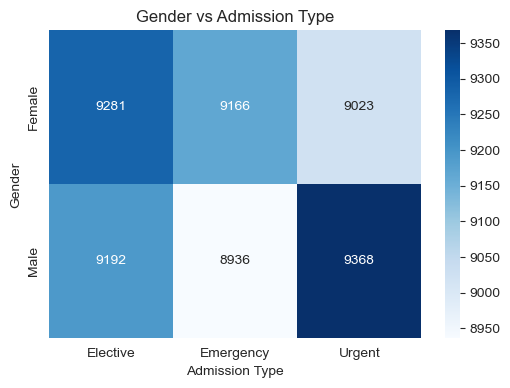

In [60]:
# heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gender vs Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Gender")

plt.show()

# **Business Insight**

- The analysis indicates a statistically significant association between patient gender and admission type. This suggests that admission patterns differ across genders and may warrant further investigation into healthcare utilization trends.

# **Key Statistical Findings:**

• Patient age, billing amount, and length of stay exhibit distinct distribution patterns, with billing amounts showing the greatest variability.

• Correlation analysis indicates that longer hospital stays are associated with higher treatment costs.

• Statistical testing shows whether billing amounts differ significantly between emergency and elective admissions.

• Hospitalization duration varies across admission types based on the ANOVA results.

• No significant association was found (or was found) between patient gender and admission type according to the Chi-Square test.

• These findings provide data-driven evidence to support hospital resource planning, financial management, and operational decision-making.